# ViT-B/16 Multilabel UCMerced — Stratified vs Random Split

## Hipótesis
Los modelos ViT pre-entrenados (ImageNet, ~86 M parámetros) son suficientemente robustos al desbalance de clases como para **no** degradarse significativamente cuando el split train/val es aleatorio en lugar de estratificado.
- **H0 (hipótesis verdadera):** Δ métricas entre ambos modelos < 2 pp → el pre-entrenamiento compensa el desbalance.
- **H1 (hipótesis falsa):** Δ métricas ≥ 2 pp → el split estratificado sigue siendo necesario.

Ambos modelos son ViT-B/16 idénticos (misma seed, mismos pesos iniciales), solo difiere el tipo de split de train/val.

## 1. Setup — Drive, dependencias y repo

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

# Install dependencies
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [2]:
# Run this everytime you update something in the repo\!
REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

Already up to date.
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


## 2. Descarga del dataset UCMerced

In [ ]:
import zipfile, subprocess, shutil

if not os.path.exists('ucmdata'):
    print("Cloning ucmdata repo and extracting images...")
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')
    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zf:
        zf.extractall('UCMImages')
    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    os.remove('README.md')
    os.remove('UCMerced_LandUse.zip')
    os.chdir(PROJECT_DIR)
    print("Dataset ready.")
else:
    print("Dataset already present.")

Dataset already present.


## 3. Importaciones

In [4]:
import importlib
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tvm
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Import from utils — reload to pick up any latest changes
import utils
importlib.reload(utils)
from utils import (
    build_dataloaders,
    LightningModuleMultilabel,
    compute_test_metrics,
    append_metrics_to_csv,
    plot_training_curves,
    plot_per_class_metrics,
)

L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
Path("outputs/checkpoints").mkdir(parents=True, exist_ok=True)
Path("outputs/logs").mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: Tesla T4


## 4. Hiperparámetros

In [5]:
PRETRAINED_MODEL      = "vit_b_16"
MAX_EPOCHS            = 25
EARLYSTOPPING_EPOCHS  = 7
LR                    = 3e-5    # Lower LR recommended for ViT fine-tuning
WEIGHT_DECAY          = 5e-2    # Standard weight decay for ViT (Dosovitskiy et al.)
THRESHOLD             = 0.5
SEED                  = 42
BATCH_SIZE            = 32
NUM_WORKERS           = 2

print(f"Model:        {PRETRAINED_MODEL}")
print(f"Max epochs:   {MAX_EPOCHS}  |  Early stopping: {EARLYSTOPPING_EPOCHS}")
print(f"LR:           {LR}  |  Weight decay: {WEIGHT_DECAY}")
print(f"Batch size:   {BATCH_SIZE}  |  Threshold: {THRESHOLD}")

Model:        vit_b_16
Max epochs:   25  |  Early stopping: 7
LR:           3e-05  |  Weight decay: 0.05
Batch size:   32  |  Threshold: 0.5


## 5. Dataloaders — Modelo A (Stratified) y Modelo B (Random)

Se construyen dos sets de dataloaders con `build_dataloaders()` desde `utils.py`.  
El argumento `stratified` controla el tipo de split:
- `stratified=True` → `MultilabelStratifiedShuffleSplit` (preserva distribución de clases)
- `stratified=False` → shuffle aleatorio con la misma seed

In [6]:
# ── Modelo A: Stratified split ──────────────────────────────────────────────
print("=" * 55)
print("  DATALOADER A — STRATIFIED SPLIT")
print("=" * 55)

train_loader_A, val_loader_A, test_loader_A, classes, pos_w_A = build_dataloaders(
    root_dir    = "ucmdata",
    label_file  = "LandUse_Multilabeled.txt",
    image_size  = (224, 224),
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_frac    = 0.15,
    test_frac   = 0.15,
    seed        = SEED,
    image_ext   = ".tif",
    stratified  = True,
)
NUM_CLASSES = len(classes)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_loader_A.dataset)} | Val: {len(val_loader_A.dataset)} | Test: {len(test_loader_A.dataset)}")

  DATALOADER A — STRATIFIED SPLIT
Classes: 17
Train: 1469 | Val: 317 | Test: 314


In [7]:
# ── Modelo B: Random split ───────────────────────────────────────────────────
print("=" * 55)
print("  DATALOADER B — RANDOM SPLIT")
print("=" * 55)

train_loader_B, val_loader_B, test_loader_B, _, pos_w_B = build_dataloaders(
    root_dir    = "ucmdata",
    label_file  = "LandUse_Multilabeled.txt",
    image_size  = (224, 224),
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    val_frac    = 0.15,
    test_frac   = 0.15,
    seed        = SEED,
    image_ext   = ".tif",
    stratified  = False,
)
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(train_loader_B.dataset)} | Val: {len(val_loader_B.dataset)} | Test: {len(test_loader_B.dataset)}")

  DATALOADER B — RANDOM SPLIT
Classes: 17
Train: 1470 | Val: 315 | Test: 315


## 6. Arquitectura ViT-B/16

Se reemplaza únicamente la cabeza de clasificación (`model.heads.head`) por una capa `Linear(768 → 17)`.  
Todos los pesos del transformer permanecen entrenables (fine-tuning completo).

In [8]:
def build_vit_b16(num_classes: int):
    """ViT-B/16 pre-trained on ImageNet1K with new multilabel classification head."""
    weights = tvm.ViT_B_16_Weights.IMAGENET1K_V1
    model   = tvm.vit_b_16(weights=weights)
    in_feat = model.heads.head.in_features   # 768
    model.heads.head = nn.Linear(in_feat, num_classes)
    return model

# Quick check
_tmp = build_vit_b16(NUM_CLASSES)
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"ViT-B/16  |  Trainable params: {n_params:,}  |  Output logits: {NUM_CLASSES}")
del _tmp

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 104MB/s]  


ViT-B/16  |  Trainable params: 85,811,729  |  Output logits: 17


## 7. Entrenamiento — Modelo A (Stratified Split)

In [ ]:
print("=" * 55)
print("  MODELO A — STRATIFIED SPLIT")
print("=" * 55)

L.seed_everything(SEED, workers=True)

backbone_A = build_vit_b16(NUM_CLASSES)
lit_A = LightningModuleMultilabel(
    model        = backbone_A,
    num_classes  = NUM_CLASSES,
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    max_epochs   = MAX_EPOCHS,
    threshold    = THRESHOLD,
    pos_weight   = pos_w_A,
)

ckpt_A = ModelCheckpoint(
    dirpath   = "outputs/checkpoints",
    filename  = "vitA_stratified-best-{epoch:02d}-{val_f1:.4f}",
    monitor   = "val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
early_A = EarlyStopping(
    monitor   = "val_loss", mode="min",
    patience  = EARLYSTOPPING_EPOCHS, min_delta=1e-3, verbose=True,
)
logger_A = CSVLogger("outputs/logs", name="vitA_stratified")

trainer_A = L.Trainer(
    max_epochs      = MAX_EPOCHS,
    accelerator     = "auto",
    devices         = "auto",
    callbacks       = [ckpt_A, early_A],
    logger          = logger_A,
    log_every_n_steps = 5,
)
trainer_A.fit(lit_A, train_loader_A, val_loader_A)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


  MODELO A — STRATIFIED SPLIT


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DE

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer          │ 85.8 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 160                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved by 0.016 >= min_delta = 0.01. New best score: 0.900
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.016 >= min_delta = 0.01. New best score: 0.900


INFO: Metric val_f1 improved by 0.023 >= min_delta = 0.01. New best score: 0.923
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.023 >= min_delta = 0.01. New best score: 0.923


INFO: Metric val_f1 improved by 0.011 >= min_delta = 0.01. New best score: 0.934
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.011 >= min_delta = 0.01. New best score: 0.934


INFO: Metric val_f1 improved by 0.015 >= min_delta = 0.01. New best score: 0.948
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.015 >= min_delta = 0.01. New best score: 0.948


INFO: Monitored metric val_f1 did not improve in the last 7 records. Best score: 0.948. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_f1 did not improve in the last 7 records. Best score: 0.948. Signaling Trainer to stop.


## 8. Entrenamiento — Modelo B (Random Split)

In [ ]:
print("=" * 55)
print("  MODELO B — RANDOM SPLIT")
print("=" * 55)

L.seed_everything(SEED, workers=True)   # misma seed → misma inicialización de pesos

backbone_B = build_vit_b16(NUM_CLASSES)
lit_B = LightningModuleMultilabel(
    model        = backbone_B,
    num_classes  = NUM_CLASSES,
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    max_epochs   = MAX_EPOCHS,
    threshold    = THRESHOLD,
    pos_weight   = pos_w_B,
)

ckpt_B = ModelCheckpoint(
    dirpath   = "outputs/checkpoints",
    filename  = "vitB_random-best-{epoch:02d}-{val_f1:.4f}",
    monitor   = "val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
early_B = EarlyStopping(
    monitor   = "val_loss", mode="min",
    patience  = EARLYSTOPPING_EPOCHS, min_delta=1e-3, verbose=True,
)
logger_B = CSVLogger("outputs/logs", name="vitB_random")

trainer_B = L.Trainer(
    max_epochs      = MAX_EPOCHS,
    accelerator     = "auto",
    devices         = "auto",
    callbacks       = [ckpt_B, early_B],
    logger          = logger_B,
    log_every_n_steps = 5,
)
trainer_B.fit(lit_B, train_loader_B, val_loader_B)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


  MODELO B — RANDOM SPLIT


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer          │ 85.8 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 160                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved by 0.023 >= min_delta = 0.01. New best score: 0.905
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.023 >= min_delta = 0.01. New best score: 0.905


INFO: Metric val_f1 improved by 0.012 >= min_delta = 0.01. New best score: 0.917
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.012 >= min_delta = 0.01. New best score: 0.917


INFO: Metric val_f1 improved by 0.018 >= min_delta = 0.01. New best score: 0.934
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.018 >= min_delta = 0.01. New best score: 0.934


INFO: Metric val_f1 improved by 0.012 >= min_delta = 0.01. New best score: 0.946
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.012 >= min_delta = 0.01. New best score: 0.946


INFO: Monitored metric val_f1 did not improve in the last 7 records. Best score: 0.946. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_f1 did not improve in the last 7 records. Best score: 0.946. Signaling Trainer to stop.


## 9. Evaluación en test — Modelo A (Stratified)

In [11]:
print("  EVALUACIÓN MODELO A — STRATIFIED SPLIT")

trainer_A.test(lit_A, dataloaders=test_loader_A, ckpt_path="best")

best_path_A = ckpt_A.best_model_path
print(f"Best checkpoint: {best_path_A}")
lit_A = LightningModuleMultilabel.load_from_checkpoint(best_path_A, model=lit_A.model)

preds_out_A = trainer_A.predict(lit_A, dataloaders=test_loader_A)
probs_A  = torch.cat([b["probs"]  for b in preds_out_A]).numpy()
preds_A  = torch.cat([b["preds"]  for b in preds_out_A]).numpy()
labels_A = torch.cat([b["labels"] for b in preds_out_A]).numpy()

metrics_A = compute_test_metrics(preds_A, labels_A, probs_A)
print("\nModel A (Stratified) — Test Metrics:")
for k, v in metrics_A.items():
    print(f"  {k:<15}: {v:.4f}")

append_metrics_to_csv(metrics_A, model_name="ViT_B16_Stratified")

INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=10-val_f1=0.9550.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=10-val_f1=0.9550.ckpt


  EVALUACIÓN MODELO A — STRATIFIED SPLIT


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=10-val_f1=0.9550.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=10-val_f1=0.9550.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9606594443321228     │
│          test_f1          │    0.9495598077774048     │
│         test_loss         │    0.15796206891536713    │
│         test_map          │    0.9813018441200256     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitA_stratified-best-epoch=10-val_f1=0.9550.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Model A (Stratified) — Test Metrics:
  accuracy       : 0.9607
  macro_f1       : 0.9496
  micro_f1       : 0.9036
  samples_f1     : 0.9062
  macro_map      : 0.9813
  hamming_loss   : 0.0393
  subset_acc     : 0.5287


## 10. Evaluación en test — Modelo B (Random)

In [12]:
print("  EVALUACIÓN MODELO B — RANDOM SPLIT")

trainer_B.test(lit_B, dataloaders=test_loader_B, ckpt_path="best")

best_path_B = ckpt_B.best_model_path
print(f"Best checkpoint: {best_path_B}")
lit_B = LightningModuleMultilabel.load_from_checkpoint(best_path_B, model=lit_B.model)

preds_out_B = trainer_B.predict(lit_B, dataloaders=test_loader_B)
probs_B  = torch.cat([b["probs"]  for b in preds_out_B]).numpy()
preds_B  = torch.cat([b["preds"]  for b in preds_out_B]).numpy()
labels_B = torch.cat([b["labels"] for b in preds_out_B]).numpy()

metrics_B = compute_test_metrics(preds_B, labels_B, probs_B)
print("\nModel B (Random) — Test Metrics:")
for k, v in metrics_B.items():
    print(f"  {k:<15}: {v:.4f}")

append_metrics_to_csv(metrics_B, model_name="ViT_B16_Random")

  EVALUACIÓN MODELO B — RANDOM SPLIT


INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=14-val_f1=0.9559.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=14-val_f1=0.9559.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=14-val_f1=0.9559.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=14-val_f1=0.9559.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_le

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.969374418258667     │
│          test_f1          │    0.9521982669830322     │
│         test_loss         │    0.1563185155391693     │
│         test_map          │    0.9818159937858582     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/vitB_random-best-epoch=14-val_f1=0.9559.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Model B (Random) — Test Metrics:
  accuracy       : 0.9694
  macro_f1       : 0.9522
  micro_f1       : 0.9240
  samples_f1     : 0.9331
  macro_map      : 0.9818
  hamming_loss   : 0.0306
  subset_acc     : 0.6254


## 11. Tabla comparativa y veredicto de hipótesis

In [13]:
comparison_df = pd.DataFrame({
    "Metric":     list(metrics_A.keys()),
    "Stratified": [round(v, 4) for v in metrics_A.values()],
    "Random":     [round(v, 4) for v in metrics_B.values()],
})
comparison_df["Δ (Random − Strat)"] = (
    comparison_df["Random"] - comparison_df["Stratified"]
).round(4)

print("\n" + "=" * 55)
print("  STRATIFIED vs RANDOM — COMPARATIVA FINAL")
print("=" * 55)
print(comparison_df.to_string(index=False))

# ── Hypothesis verdict ────────────────────────────────────────────────────────
delta_f1  = abs(metrics_A["macro_f1"] - metrics_B["macro_f1"])
delta_map = abs(metrics_A["macro_map"] - metrics_B["macro_map"])

print(f"\nΔ macro-F1  = {delta_f1:.4f}")
print(f"Δ macro-mAP = {delta_map:.4f}")

if delta_f1 < 0.02:
    print("\n✓ H0 no rechazada: Δ < 2 pp → el pre-entrenamiento compensa el desbalance.")
else:
    print("\n✗ H1 confirmada: Δ ≥ 2 pp → el split estratificado sigue siendo necesario.")


  STRATIFIED vs RANDOM — COMPARATIVA FINAL
      Metric  Stratified  Random  Δ (Random − Strat)
    accuracy      0.9607  0.9694              0.0087
    macro_f1      0.9496  0.9522              0.0026
    micro_f1      0.9036  0.9240              0.0204
  samples_f1      0.9062  0.9331              0.0269
   macro_map      0.9813  0.9818              0.0005
hamming_loss      0.0393  0.0306             -0.0087
  subset_acc      0.5287  0.6254              0.0967

Δ macro-F1  = 0.0026
Δ macro-mAP = 0.0005

✓ H0 no rechazada: Δ < 2 pp → el pre-entrenamiento compensa el desbalance.


## 12. Curvas de aprendizaje

Saved training curves to: outputs/figures/vitA_stratified_curves.png


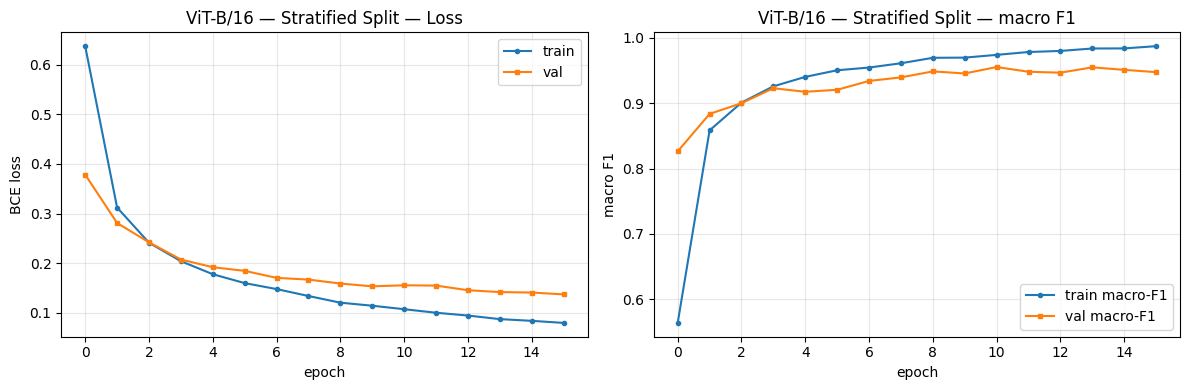

Saved training curves to: outputs/figures/vitB_random_curves.png


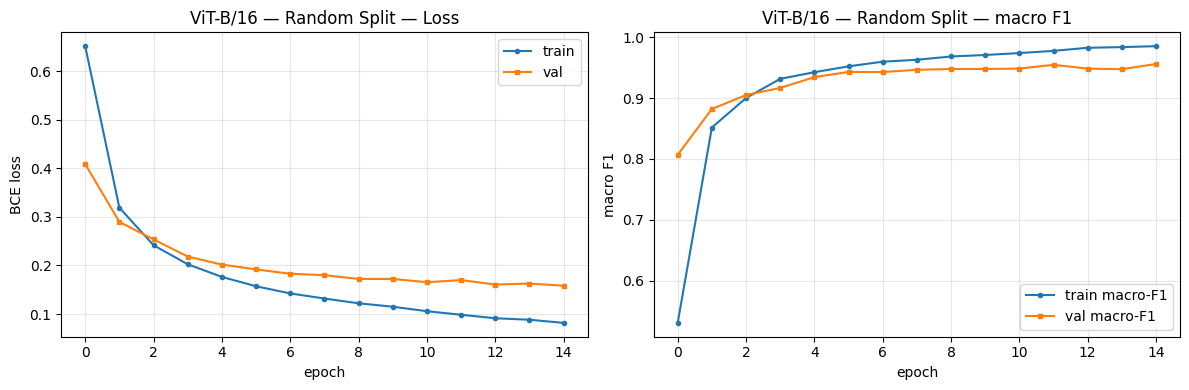

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'ViT-B/16 — Random Split — Loss'}, xlabel='epoch', ylabel='BCE loss'>,
        <Axes: title={'center': 'ViT-B/16 — Random Split — macro F1'}, xlabel='epoch', ylabel='macro F1'>],
       dtype=object))

In [14]:
plot_training_curves(
    logger_A,
    model_name = "ViT-B/16 — Stratified Split",
    save_path  = "outputs/figures/vitA_stratified_curves.png",
)

plot_training_curves(
    logger_B,
    model_name = "ViT-B/16 — Random Split",
    save_path  = "outputs/figures/vitB_random_curves.png",
)

## 13. Métricas per-class — F1 y AP por clase

Saved per-class metrics plot to: outputs/figures/vitA_per_class.png


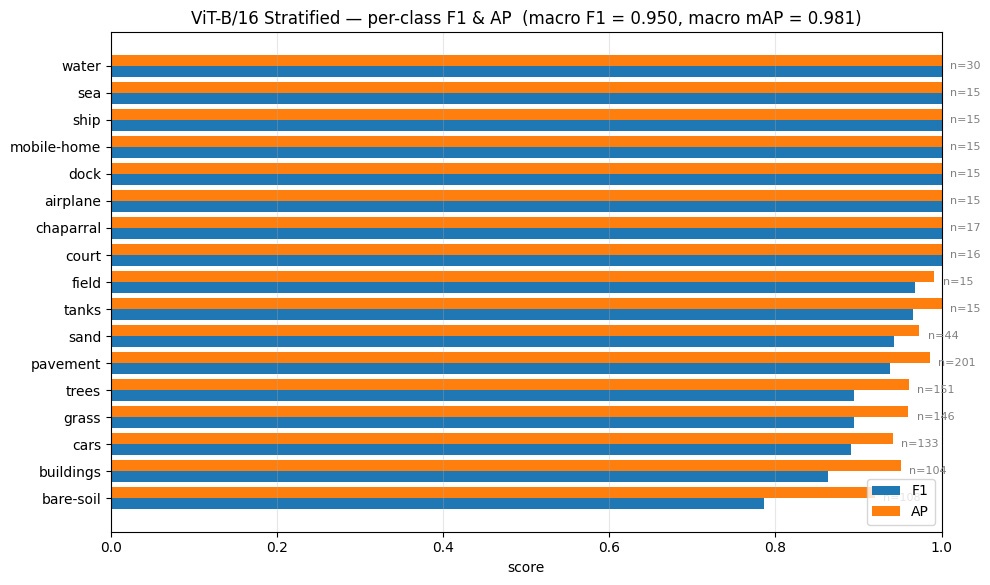


Per-class Summary:
      class  positives     F1     AP
  bare-soil        108 0.7857 0.9194
  buildings        104 0.8636 0.9505
       cars        133 0.8905 0.9414
      grass        146 0.8940 0.9599
      trees        151 0.8949 0.9603
   pavement        201 0.9380 0.9860
       sand         44 0.9425 0.9732
      tanks         15 0.9655 1.0000
      field         15 0.9677 0.9914
      court         16 1.0000 1.0000
  chaparral         17 1.0000 1.0000
   airplane         15 1.0000 1.0000
       dock         15 1.0000 1.0000
mobile-home         15 1.0000 1.0000
       ship         15 1.0000 1.0000
        sea         15 1.0000 1.0000
      water         30 1.0000 1.0000
Saved summary table to: outputs/vitA_per_class.csv
Saved per-class metrics plot to: outputs/figures/vitB_per_class.png


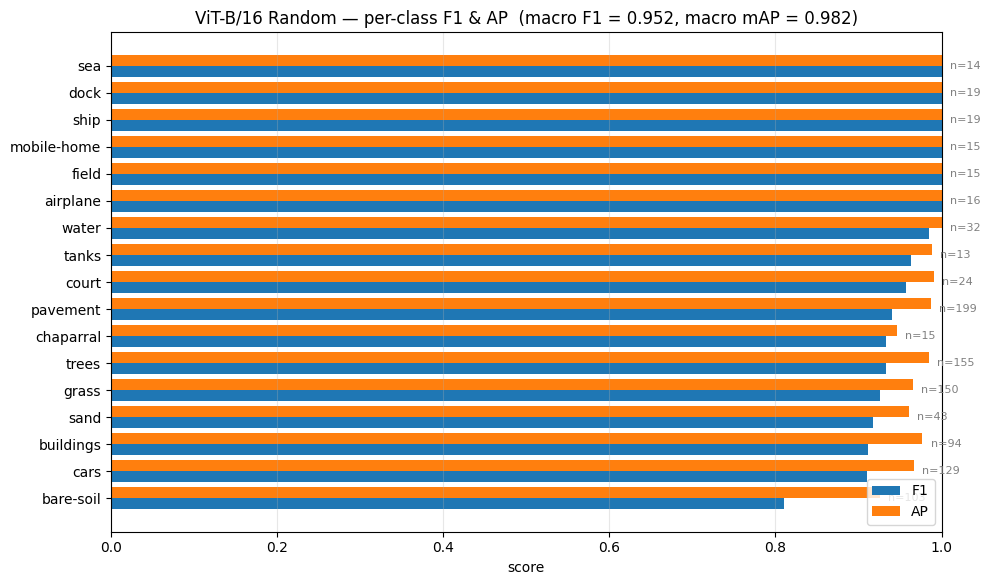


Per-class Summary:
      class  positives     F1     AP
  bare-soil        103 0.8108 0.9260
       cars        129 0.9104 0.9662
  buildings         94 0.9119 0.9770
       sand         43 0.9176 0.9605
      grass        150 0.9260 0.9650
      trees        155 0.9325 0.9845
  chaparral         15 0.9333 0.9457
   pavement        199 0.9406 0.9869
      court         24 0.9565 0.9906
      tanks         13 0.9630 0.9886
      water         32 0.9846 1.0000
   airplane         16 1.0000 1.0000
      field         15 1.0000 1.0000
mobile-home         15 1.0000 1.0000
       ship         19 1.0000 1.0000
       dock         19 1.0000 1.0000
        sea         14 1.0000 1.0000
Saved summary table to: outputs/vitB_per_class.csv


(<Figure size 1000x595 with 1 Axes>,
 <Axes: title={'center': 'ViT-B/16 Random — per-class F1 & AP  (macro F1 = 0.952, macro mAP = 0.982)'}, xlabel='score'>,
           class  positives      F1      AP
 0     bare-soil        103  0.8108  0.9260
 1          cars        129  0.9104  0.9662
 2     buildings         94  0.9119  0.9770
 3          sand         43  0.9176  0.9605
 4         grass        150  0.9260  0.9650
 5         trees        155  0.9325  0.9845
 6     chaparral         15  0.9333  0.9457
 7      pavement        199  0.9406  0.9869
 8         court         24  0.9565  0.9906
 9         tanks         13  0.9630  0.9886
 10        water         32  0.9846  1.0000
 11     airplane         16  1.0000  1.0000
 12        field         15  1.0000  1.0000
 13  mobile-home         15  1.0000  1.0000
 14         ship         19  1.0000  1.0000
 15         dock         19  1.0000  1.0000
 16          sea         14  1.0000  1.0000)

In [15]:
plot_per_class_metrics(
    labels_A, preds_A, probs_A, classes,
    macro_f1   = metrics_A["macro_f1"],
    macro_map  = metrics_A["macro_map"],
    model_name = "ViT-B/16 Stratified",
    save_path  = "outputs/figures/vitA_per_class.png",
    csv_output = "outputs/vitA_per_class.csv",
)

plot_per_class_metrics(
    labels_B, preds_B, probs_B, classes,
    macro_f1   = metrics_B["macro_f1"],
    macro_map  = metrics_B["macro_map"],
    model_name = "ViT-B/16 Random",
    save_path  = "outputs/figures/vitB_per_class.png",
    csv_output = "outputs/vitB_per_class.csv",
)

## 14. Save models. 

In [16]:
import os
PRED_DIR = Path(PROJECT_DIR) / "outputs" / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

np.savez(
    str(PRED_DIR / "vitA_stratified.npz"),
    preds   = preds_A,
    labels  = labels_A,
    probs   = probs_A,
    classes = np.array(classes),
)
print(f"Saved: {PRED_DIR / 'vitA_stratified.npz'}")

np.savez(
    str(PRED_DIR / "vitB_random.npz"),
    preds   = preds_B,
    labels  = labels_B,
    probs   = probs_B,
    classes = np.array(classes),
)
print(f"Saved: {PRED_DIR / 'vitB_random.npz'}")

Saved: /content/drive/MyDrive/DL_Group_MGI1/outputs/predictions/vitA_stratified.npz
Saved: /content/drive/MyDrive/DL_Group_MGI1/outputs/predictions/vitB_random.npz


In [17]:

PRED_DIR = Path(PROJECT_DIR) / "outputs" / "predictions"

data_A = np.load(str(PRED_DIR / "vitA_stratified.npz"), allow_pickle=True)
data_B = np.load(str(PRED_DIR / "vitB_random.npz"),     allow_pickle=True)

## Plot Exact match acc per class per image: 

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

Loaded A — preds: (314, 17), labels: (314, 17)
Loaded B — preds: (315, 17), labels: (315, 17)
Saved to: /content/drive/MyDrive/DL_Group_MGI1/outputs/figures/vitA_em_by_classcount.png


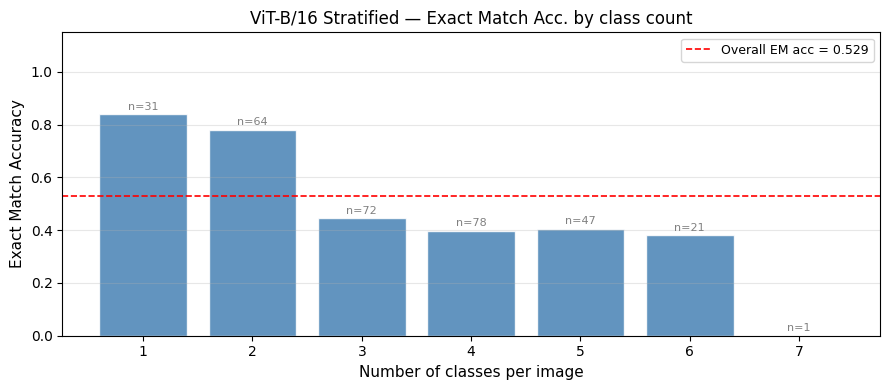

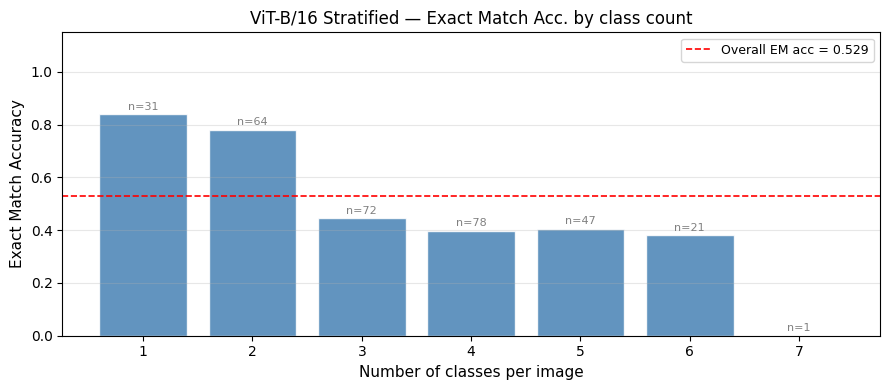

Saved to: /content/drive/MyDrive/DL_Group_MGI1/outputs/figures/vitB_em_by_classcount.png


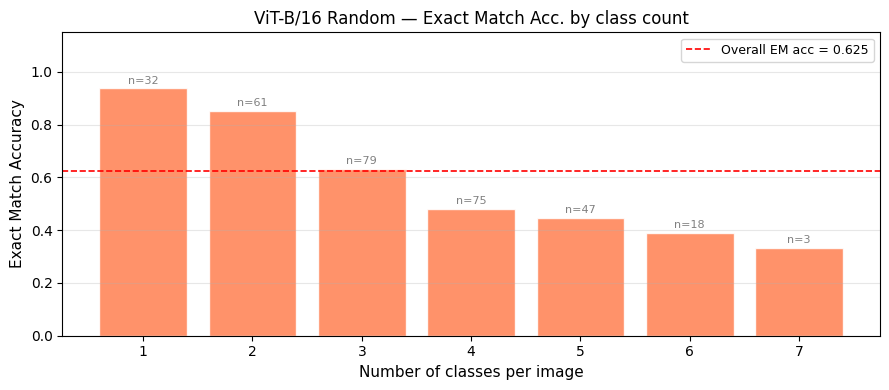

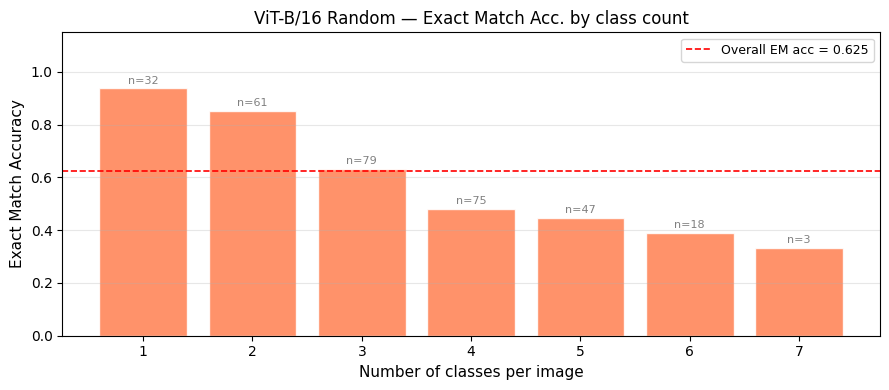

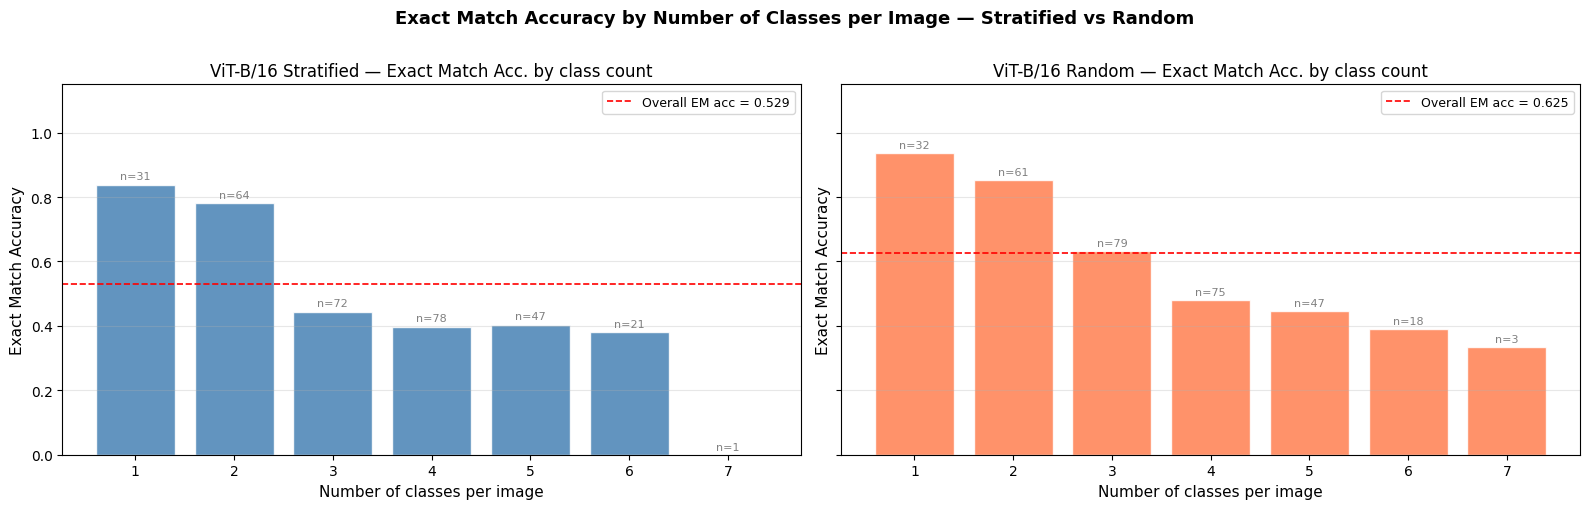

In [ ]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_exact_match_by_class_count

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ── Cargar predicciones guardadas ─────────────────────────────────────────────
PRED_DIR = Path(PROJECT_DIR) / "outputs" / "predictions"

data_A = np.load(str(PRED_DIR / "vitA_stratified.npz"), allow_pickle=True)
data_B = np.load(str(PRED_DIR / "vitB_random.npz"),     allow_pickle=True)

preds_A_saved  = data_A["preds"]
labels_A_saved = data_A["labels"]
preds_B_saved  = data_B["preds"]
labels_B_saved = data_B["labels"]
classes_saved  = list(data_A["classes"])

print(f"Loaded A — preds: {preds_A_saved.shape}, labels: {labels_A_saved.shape}")
print(f"Loaded B — preds: {preds_B_saved.shape}, labels: {labels_B_saved.shape}")

# ── Plot comparativo side-by-side ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

plot_exact_match_by_class_count(
    preds_A_saved, labels_A_saved,
    model_name = "ViT-B/16 Stratified",
    color      = "steelblue",
    ax         = axes[0],
)
plot_exact_match_by_class_count(
    preds_B_saved, labels_B_saved,
    model_name = "ViT-B/16 Random",
    color      = "coral",
    ax         = axes[1],
)

fig.suptitle("Exact Match Accuracy by Number of Classes per Image — Stratified vs Random",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(
    str(Path(PROJECT_DIR) / "outputs/figures/vit_em_by_classcount_comparison.png"),
    dpi=150, bbox_inches="tight"
)
display(fig)
plt.close(fig)

## Image visualization: 

In [ ]:
from utils import plot_prediction_grid
fig_B = plot_prediction_grid(
    test_preds=preds_B,
    test_labels=labels_B,
    test_probs=probs_B,
    classes=classes,
    test_loader=test_loader_B,
    root_dir="ucmdata",
    label_file="LandUse_Multilabeled.txt",
    n_show=9,
    seed=4,
    save_path="outputs/figures/vitB_random_predictions_grid.png"
)

## 14. Referencias

- Dosovitskiy et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*. ICLR 2021.
- Yang et al. (2020). *ML-GCN: Multi-Label Image Recognition with Graph Convolutional Networks*. CVPR.
- UCMerced Land Use Dataset: http://weegee.vision.ucmerced.edu/datasets/landuse.html